# 📊 Project Movie Recommends System `Collabrative Filtering`
Exploratory Data Analysis cho bộ dữ liệu MovieLens phiên bản `latest-small`.

In [1]:
import matplotlib
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Đọc dữ liệu
ratings = pd.read_csv(r"C:\Users\ACER\AppData\Roaming\Microsoft\Windows\Start Menu\Programs\Python 3.12\filtered_ratings_50_to_150.csv")


In [2]:

ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [3]:
# --- 1. Tổng quan dữ liệu ---
print("🎯 Kích thước dữ liệu:", ratings.shape)
print("📋 Cột dữ liệu:", list(ratings.columns))
print("\n📌 Kiểu dữ liệu:")
print(ratings.dtypes)

# --- 2. Kiểm tra dữ liệu thiếu ---
print("\n🔍 Số lượng giá trị thiếu:")
print(ratings.isnull().sum())

# --- 3. Thống kê mô tả ratings ---
print("\n📊 Thống kê mô tả:")
print(ratings['rating'].describe()) 


🎯 Kích thước dữ liệu: (6526056, 4)
📋 Cột dữ liệu: ['userId', 'movieId', 'rating', 'timestamp']

📌 Kiểu dữ liệu:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

🔍 Số lượng giá trị thiếu:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

📊 Thống kê mô tả:
count    6.526056e+06
mean     3.751343e+00
std      1.040990e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.500000e+00
max      5.000000e+00
Name: rating, dtype: float64


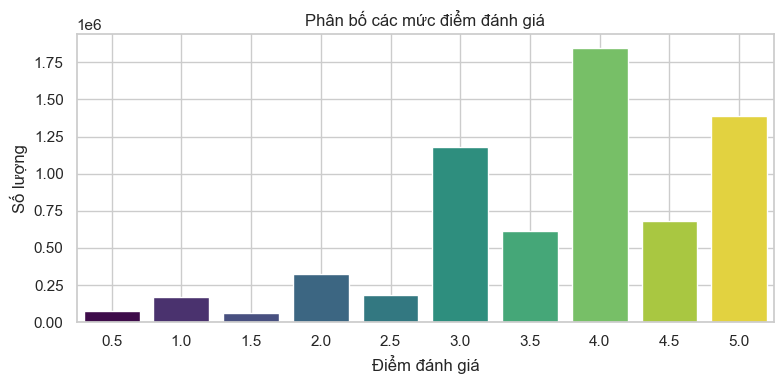

In [4]:
# --- 4. Phân bố điểm đánh giá ---
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)
plt.title('Phân bố các mức điểm đánh giá')
plt.xlabel('Điểm đánh giá')
plt.ylabel('Số lượng')
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
"""# 📊 Tính số lượt đánh giá của mỗi người dùng
user_counts = ratings['userId'].value_counts()

# 🎯 Đặt các mốc số lượt đánh giá để kiểm tra
thresholds = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]

# 📈 Tính số lượng user có lượt đánh giá >= mỗi mốc
user_distribution = {f">= {thresh}": (user_counts >= thresh).sum() for thresh in thresholds}

# 🎨 Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(x=list(user_distribution.keys()), y=list(user_distribution.values()), palette="Blues_d")
plt.title("Số lượng người dùng theo mốc số lượt đánh giá")
plt.xlabel("Số lượt đánh giá (từ mốc trở lên)")
plt.ylabel("Số người dùng")
plt.tight_layout()
plt.show()"""


'# 📊 Tính số lượt đánh giá của mỗi người dùng\nuser_counts = ratings[\'userId\'].value_counts()\n\n# 🎯 Đặt các mốc số lượt đánh giá để kiểm tra\nthresholds = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]\n\n# 📈 Tính số lượng user có lượt đánh giá >= mỗi mốc\nuser_distribution = {f">= {thresh}": (user_counts >= thresh).sum() for thresh in thresholds}\n\n# 🎨 Vẽ biểu đồ\nplt.figure(figsize=(10, 5))\nsns.barplot(x=list(user_distribution.keys()), y=list(user_distribution.values()), palette="Blues_d")\nplt.title("Số lượng người dùng theo mốc số lượt đánh giá")\nplt.xlabel("Số lượt đánh giá (từ mốc trở lên)")\nplt.ylabel("Số người dùng")\nplt.tight_layout()\nplt.show()'

In [6]:
# --- 5. Số lượng đánh giá theo người dùng ---
user_counts = ratings['userId'].value_counts()
print(f"\n👤 Số lượng người dùng: {ratings['userId'].nunique()}")
print(f"👤 Số rating trung bình mỗi user: {user_counts.mean():.2f}")
print("👤 Top 5 người dùng đánh giá nhiều nhất:")
print(user_counts.head())


👤 Số lượng người dùng: 74125
👤 Số rating trung bình mỗi user: 88.04
👤 Top 5 người dùng đánh giá nhiều nhất:
userId
240659    150
9167      150
303769    150
303794    150
184955    150
Name: count, dtype: int64


In [7]:
# --- 6. Số lượng đánh giá theo phim ---
movie_counts = ratings['movieId'].value_counts()
print(f"\n🎬 Số lượng phim: {ratings['movieId'].nunique()}")
print(f"🎬 Số rating trung bình mỗi phim: {movie_counts.mean():.2f}")
print("🎬 Top 5 phim có nhiều đánh giá nhất:")
print(movie_counts.head())



🎬 Số lượng phim: 28930
🎬 Số rating trung bình mỗi phim: 225.58
🎬 Top 5 phim có nhiều đánh giá nhất:
movieId
318     37877
356     37517
296     36844
2571    33688
593     33318
Name: count, dtype: int64


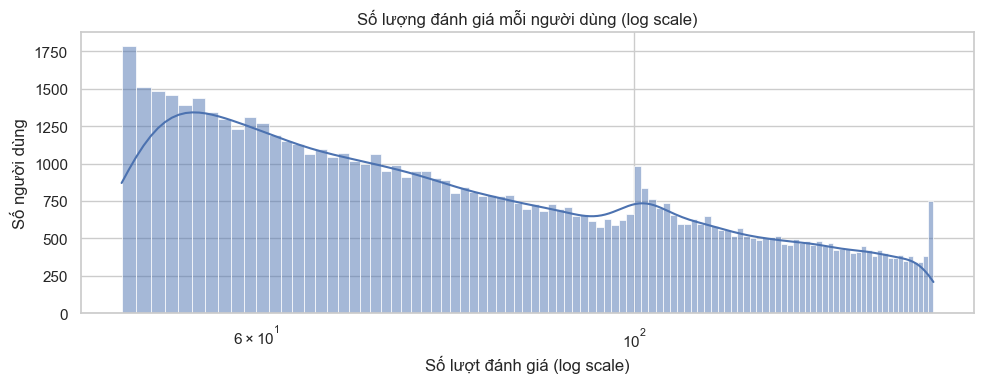

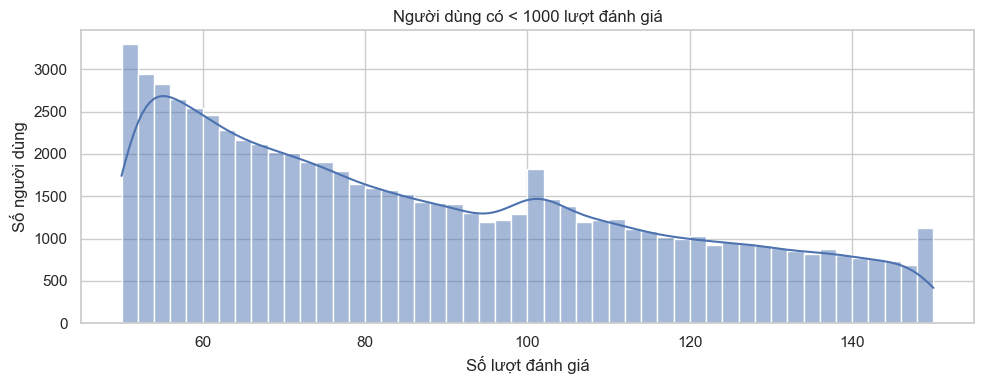

In [8]:
# --- 7. Biểu đồ số lượng rating mỗi user ---
plt.figure(figsize=(10, 4))
sns.histplot(user_counts, bins=100, kde=True)
plt.xscale('log')  # ✅ thêm log scale để phân hóa tốt hơn
plt.title('Số lượng đánh giá mỗi người dùng (log scale)')
plt.xlabel('Số lượt đánh giá (log scale)')
plt.ylabel('Số người dùng')
plt.tight_layout()
plt.show()

# Hoặc vẽ thêm phiên bản đã loại outlier
plt.figure(figsize=(10, 4))
sns.histplot(user_counts[user_counts < 1000], bins=50, kde=True)
plt.title('Người dùng có < 1000 lượt đánh giá')
plt.xlabel('Số lượt đánh giá')
plt.ylabel('Số người dùng')
plt.tight_layout()
plt.show()


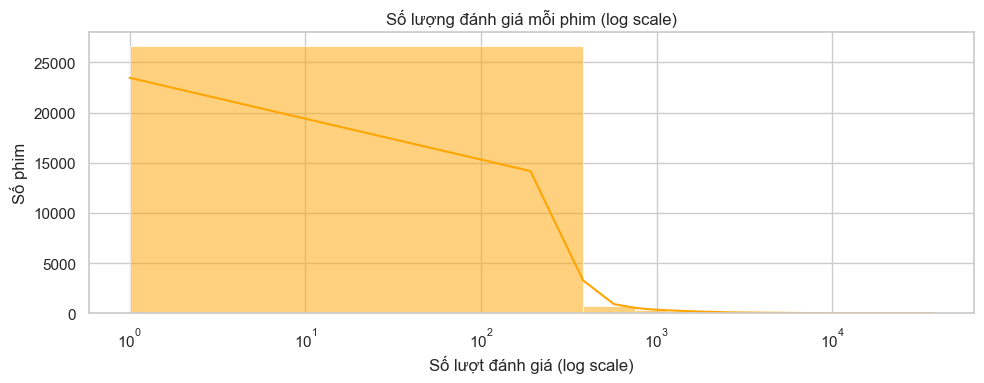

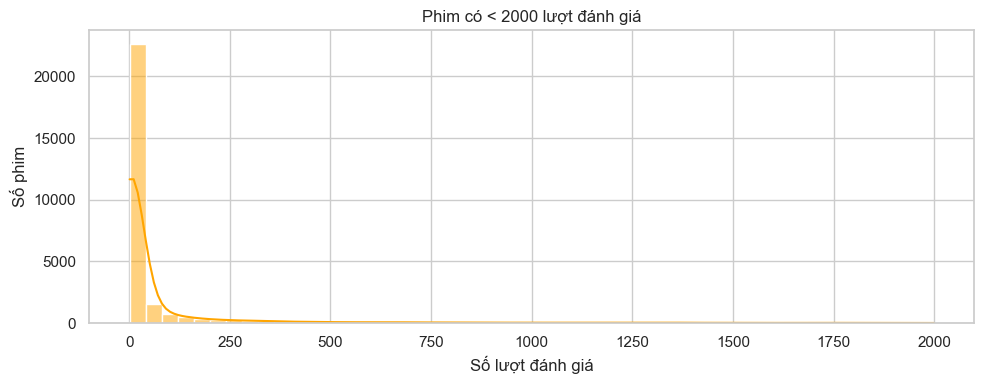

In [9]:
# --- 8. Biểu đồ số lượng rating mỗi phim ---
plt.figure(figsize=(10, 4))
sns.histplot(movie_counts, bins=100, kde=True, color='orange')
plt.xscale('log')  # ✅ log scale giúp không bị "nghẹt trái"
plt.title('Số lượng đánh giá mỗi phim (log scale)')
plt.xlabel('Số lượt đánh giá (log scale)')
plt.ylabel('Số phim')
plt.tight_layout()
plt.show()

# Thêm phiên bản lọc phim có ít hơn 2000 rating
plt.figure(figsize=(10, 4))
sns.histplot(movie_counts[movie_counts < 2000], bins=50, kde=True, color='orange')
plt.title('Phim có < 2000 lượt đánh giá')
plt.xlabel('Số lượt đánh giá')
plt.ylabel('Số phim')
plt.tight_layout()
plt.show()


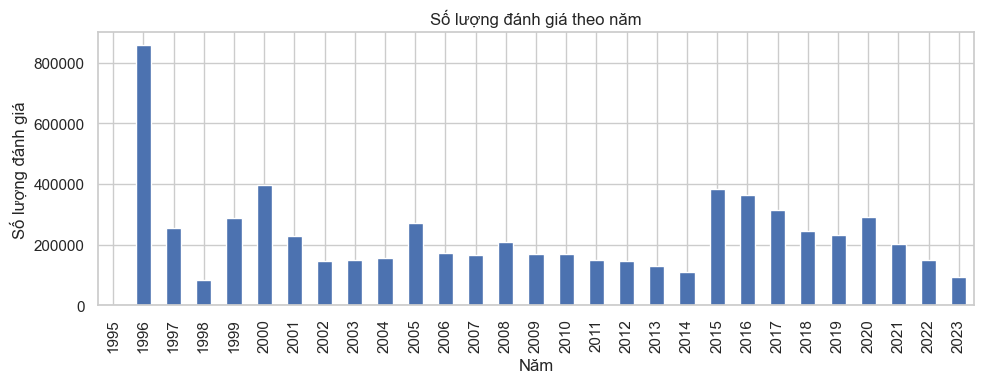

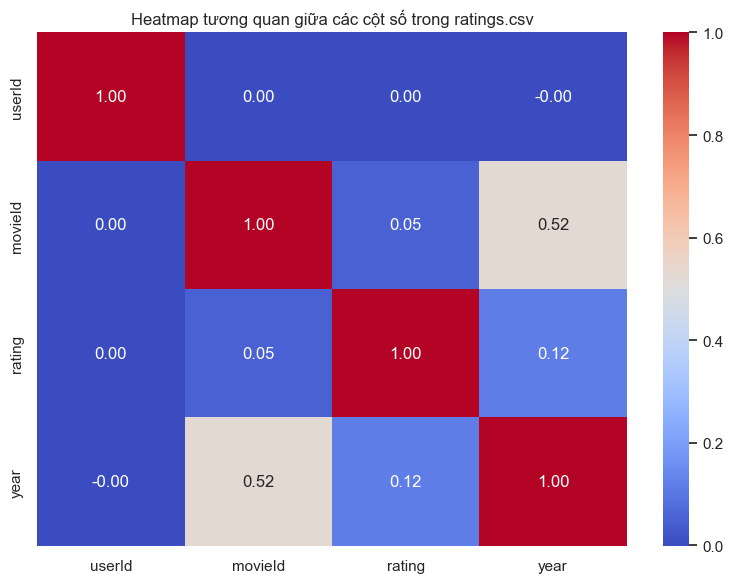

In [10]:
# --- 9. Rating theo thời gian ---
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['timestamp'].dt.year

plt.figure(figsize=(10, 4))
ratings.groupby('year').size().plot(kind='bar', title='Số lượng đánh giá theo năm')
plt.xlabel('Năm')
plt.ylabel('Số lượng đánh giá')
plt.tight_layout()
plt.show()

corr = ratings[['userId', 'movieId', 'rating', 'year']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap tương quan giữa các cột số trong ratings.csv')
plt.tight_layout()
plt.show()

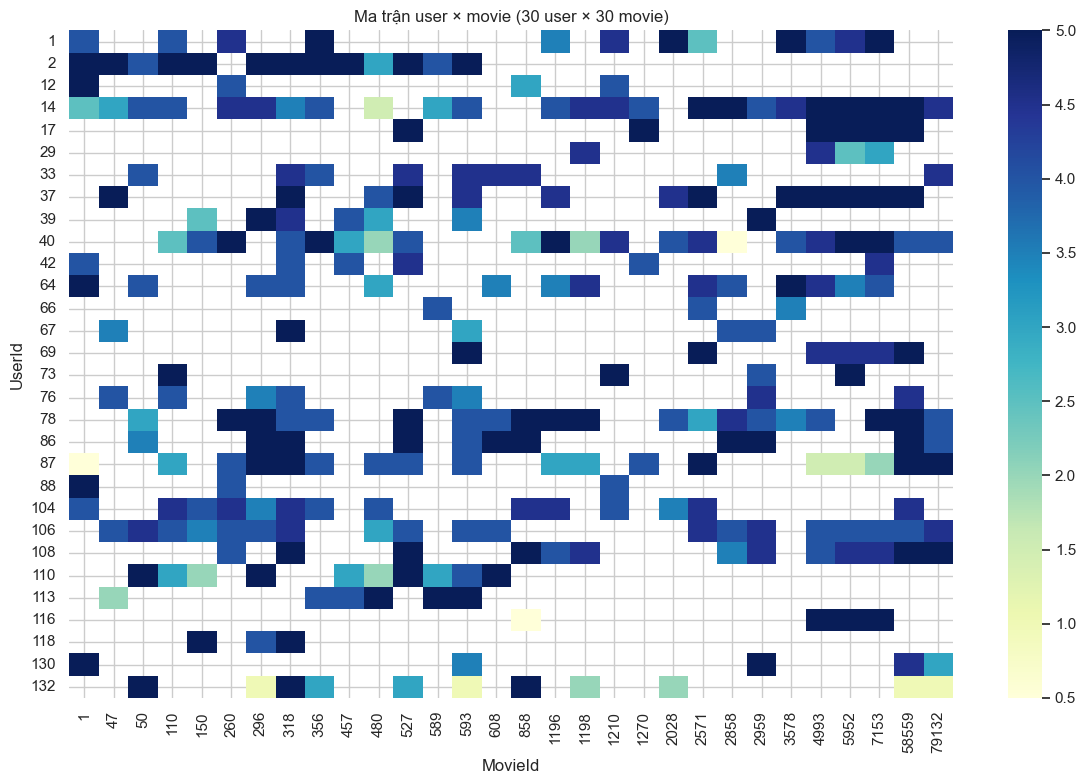

In [11]:
# Chọn ra 30 user đầu tiên
top_users = ratings['userId'].unique()[:30]

# Chọn 30 movie được đánh giá nhiều nhất
top_movies = ratings['movieId'].value_counts().head(30).index

# Lọc dataset ban đầu
filtered_ratings = ratings[
    (ratings['userId'].isin(top_users)) &
    (ratings['movieId'].isin(top_movies))
]

# Pivot ma trận nhỏ
user_movie_matrix = filtered_ratings.pivot(index='userId', columns='movieId', values='rating')

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(user_movie_matrix, annot=False, cmap="YlGnBu", cbar=True)
plt.title("Ma trận user × movie (30 user × 30 movie)")
plt.xlabel("MovieId")
plt.ylabel("UserId")
plt.tight_layout()
plt.show()


In [12]:
Phần này của CBF


SyntaxError: invalid syntax (3257506279.py, line 1)

In [ ]:

# Phân tích thể loại phổ biến
genres_exploded = movies['genres'].str.split('|').explode()
top_genres = genres_exploded.value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title("Phổ biến thể loại phim")
plt.xlabel("Số lượng phim")
plt.ylabel("Thể loại")
plt.tight_layout()
plt.show()

In [ ]:


# Top 20 tag phổ biến
top_tags = tags['tag'].value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='magma')
plt.title("Top 20 tags phổ biến")
plt.xlabel("Tần suất")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()


In [ ]:

# --- 2. Phân tích phổ biến thể loại ---
genres_exploded = movies['genres'].str.split('|').explode()
top_genres = genres_exploded.value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')

plt.title("🎬 Phổ biến thể loại phim")
plt.xlabel("Số lượng phim")
plt.ylabel("Thể loại")
plt.tight_layout()
plt.show()


In [ ]:

# --- 3. Top 20 tags phổ biến ---
top_tags = tags['tag'].value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='magma')
plt.title("🏷️ Top 20 tags phổ biến")
plt.xlabel("Tần suất")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()
